# **ARIN5103: Foundations of Machine Learning Fall 2025 Assignment 2**

### Yang,Fengshuo  21216054

### **Q2. K-Means Clustering**

The following is the provided initial code, and some preloading tasks has been
added.So please run the following code at first.

In [29]:
import numpy as np
from sklearn.metrics import pairwise_distances_argmin
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Prepare a Datasets for some results can performed, according to Q2.3
X, y_true = make_blobs(
    n_samples=300,
    centers=5,
    cluster_std=1.0,
    random_state=42
)

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. Assign labels based on closest center
        labels = pairwise_distances_argmin(X, centers)

        # 2b. Find new centers from means of points
        new_centers = np.array([X[labels == i].mean(0) for i in range(n_clusters)])

        # 2c. Check for convergence
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

**1. Modify the Provided Code to Calculate SSE:**

In [ ]:
def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. Assign labels based on closest center
        labels = pairwise_distances_argmin(X, centers)

        # 2b. Find new centers from means of points
        new_centers = np.array([X[labels == i].mean(0) for i in range(n_clusters)])

        # 2c. Calculate SSE(Sum of Squared Errors)
        sse = 0.0
        for cluster in range(n_clusters):
            cluster_samples = X[labels == cluster]
            # Compute the squared Euclidean distances from the sample to the center
            sse += np.sum((cluster_samples - centers[cluster]) ** 2)

        # 2d. Check for convergence
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels, sse

# For testing
test_centers, test_labels, test_sse = find_clusters(X, n_clusters=2, rseed=0)
print(f"shape of centers: {test_centers.shape}, shape of labels: {test_labels.shape}, SSE: {test_sse:.2f}")

shape of centers: (2, 2), shape of labels: (300,), SSE: 10128.27


**2. Implement the n_init Strategy:**

In [ ]:
def find_best_clusters(X, n_clusters, n_init):
    # Initialization
    best_sse = np.inf
    best_centers = None
    best_labels = None

    # Replace rseed by n_init
    for rseed in range(n_init):
        # Call find_clusters() for new outputs
        centers, labels, sse = find_clusters(X, n_clusters, rseed=rseed)

        # Update the performance
        if sse < best_sse:
            best_sse = sse
            best_centers = centers
            best_labels = labels

    return best_centers, best_labels, best_sse

# For testing
best_centers, best_labels, best_sse = find_best_clusters(X, n_clusters=2, n_init=10)
print(f"Bset clusters - shape of centers: {best_centers.shape}, shape of labels: {test_labels.shape} SSE: {best_sse:.2f}")

Bset clusters - shape of centers: (2, 2), shape of labels: (300,) SSE: 8476.43


**3. Apply the Elbow Method with Your Implementation:**

In [ ]:
# List for storation
sse_list = []

# a range of cluster counts k from 2 to 9
for k in range(2, 10):
    # Judge the best SSE for each k
    _, _, best_sse = find_best_clusters(X, n_clusters=k, n_init=10)
    sse_list.append(best_sse)
    print(f"For k = {k}, best solution shows SSE = {best_sse:.2f}")

# The whole list
sse_list = [round(float(sse), 2) for sse in sse_list]
print(f"\n{sse_list}")

For k = 2, best solution shows SSE = 8476.43
For k = 3, best solution shows SSE = 2096.26
For k = 4, best solution shows SSE = 861.16
For k = 5, best solution shows SSE = 556.08
For k = 6, best solution shows SSE = 499.53
For k = 7, best solution shows SSE = 454.56
For k = 8, best solution shows SSE = 414.19
For k = 9, best solution shows SSE = 377.28

[8476.43, 2096.26, 861.16, 556.08, 499.53, 454.56, 414.19, 377.28]


**4. Plot and Analyze the Elbow Curve:**

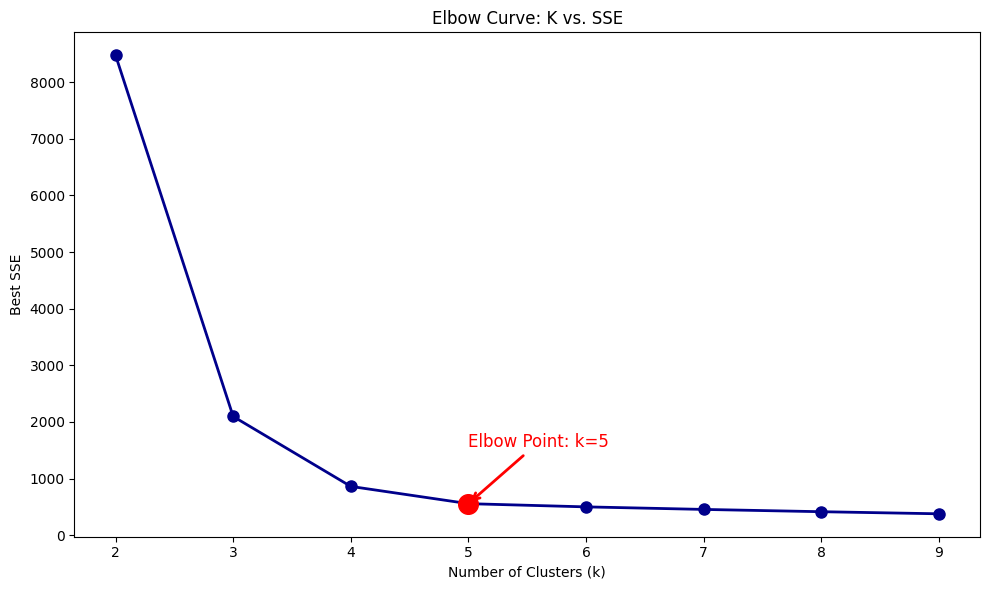

In [ ]:
# the Elobow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(2,10), sse_list, marker='o', linewidth=2, markersize=8, color='darkblue')

# Discussion for elbow point
elbow_k = 5
elbow_sse = sse_list[elbow_k - 2]
plt.scatter(elbow_k, elbow_sse, color='red', s=200, zorder=5)
plt.annotate(f'Elbow Point: k={elbow_k}',
             color = 'red',
             xy=(elbow_k, elbow_sse),
             xytext=(elbow_k, elbow_sse + 1000),
             fontsize=12,
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.title('Elbow Curve: K vs. SSE')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Best SSE')
plt.xticks(range(2,10))
plt.tight_layout()
plt.show()

From this elbow curve, it can be observed that

when **k = 5,** the rate of decrease in SSE slows down significantly, and as k continues to increase, the magnitude of the decrease in SSE yet becomes minimal.So we define this point a distinct **"elbow point".**
Therefore, the optimal number of clusters for this dataset is 5, which is perfectly consistent with the **centers = 5** parameter set when generating the data using make_blobs.

For **left side** of the elbow point k < 5: intra-cluster variance is large, SSE decreases rapidly, and the model is underfitted.


For **right side** of the elbow point k > 5: the clustering becomes overly fine-grained.


The elbow point represents a **balance** between "minimizing intra-cluster variance" and "minimizing model complexity," and it serves as the core basis for selecting the **optimal k**.